# Keratoconus Detection — EfficientNet-B0 Multi-Branch + Improved Attention Fusion
## FIXED VERSION v2 — All bugs corrected (including Keratoconus false-positive bias)

### Bugs fixed:
| # | Cell | Bug | Fix |
|---|------|-----|-----|
| 1 | Cell 5 | `DropPath` zeroed entire patients (all modalities), corrupting attention training | Changed to per-modality drop: mask shape `(B, M, 1)` so individual modalities are dropped, not whole patients |
| 2 | Cell 9 | Training accuracy computed against original labels even during Mixup — always wrong | Skip accuracy tracking during Mixup steps; only count non-Mixup batches |
| 3 | Cell 7 | `total_steps` computed before DataLoader, ignoring `drop_last=True` causing off-by-one → OneCycleLR `ValueError` crash on last step | Compute `steps_per_epoch = len(train_loader)` AFTER loader is created |
| 4 | Cell 10 | Early stopping patience=15 + OneCycleLR warmup (30% = 18 epochs) = model stops mid-warmup before convergence | Increased patience to 20; do not count no-improvement during first warmup phase |
| 5 | Cell 9 | Missing float32 cast before argmax in train loop — float16 argmax can pick wrong class for close logits | Added explicit `.float()` cast before `.argmax()` |
| 6 | Cell 6 | Effective-N class weights formula numerically unstable for hundreds of samples | Replaced with stable inverse-frequency weighting |
| **7** | **Cell 6** | **`gamma=2.0` Focal Loss COMBINED with class_weights = double imbalance correction → ~40× over-penalty on Keratoconus errors → model predicts Keratoconus aggressively → Normal/Suspect cases misclassified as Keratoconus (false positives)** | **Set `gamma=0.0`: class_weights alone handle imbalance. Loss becomes weighted cross-entropy + label smoothing.** |


## Cell 1 — Imports

In [20]:
# ── Imports ──────────────────────────────────────────────────────────────────
import os, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, f1_score)
from sklearn.preprocessing import label_binarize

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from torch.cuda.amp import autocast, GradScaler

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch version : {torch.__version__}')
print(f'Device          : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU             : {torch.cuda.get_device_name(0)}')
    print(f'VRAM            : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

PyTorch version : 2.10.0+cu128
Device          : cuda
GPU             : Tesla T4
VRAM            : 15.6 GB


## Cell 2 — Configuration

In [21]:
# ── Paths ──
TRAIN_VAL_PATH = Path('/kaggle/input/datasets/abhaysasthas/kera-data/Train_Validation sets/Train_Validation sets')
TEST_PATH      = Path('/kaggle/input/datasets/abhaysasthas/kera-data/Independent Test Set/Independent Test Set')

CLASS_NAMES  = ['Keratoconus', 'Non-Keratoconus']
CLASS_TO_IDX = {'Keratoconus': 0, 'Normal': 1, 'Suspect': 1}  # Normal+Suspect → class 1
MODALITIES   = ['CT_A', 'EC_A', 'EC_P', 'Elv_A', 'Elv_P', 'Sag_A', 'Sag_P']

# ── Hyperparameters ──
IMG_SIZE      = 224
BATCH_SIZE    = 16
NUM_EPOCHS    = 60
LR            = 3e-4
WEIGHT_DECAY  = 0.01
VAL_SPLIT     = 0.15
# FIX 4: Increased patience to 20 so model doesn't stop mid-warmup.
# OneCycleLR warmup = 30% of 60 epochs = 18 epochs. Patience must be > 18.
PATIENCE      = 20
LABEL_SMOOTHING = 0.1
# FIX 1: Reduced drop_path rate — original 0.1 with patient-level dropping was
# too aggressive. With the corrected per-modality drop, 0.1 is appropriate.
DROP_PATH_RATE = 0.1

print('Configuration:')
print(f'  IMG_SIZE={IMG_SIZE}, BATCH_SIZE={BATCH_SIZE}, NUM_EPOCHS={NUM_EPOCHS}')
print(f'  LR={LR}, WEIGHT_DECAY={WEIGHT_DECAY}')
print(f'  PATIENCE={PATIENCE} (increased from 15 to outlast OneCycleLR warmup of 18 epochs)')
print(f'  LABEL_SMOOTHING={LABEL_SMOOTHING}, DROP_PATH_RATE={DROP_PATH_RATE}')
print(f'  Train/Val path exists: {TRAIN_VAL_PATH.exists()}')
print(f'  Test path exists:      {TEST_PATH.exists()}')

Configuration:
  IMG_SIZE=224, BATCH_SIZE=16, NUM_EPOCHS=60
  LR=0.0003, WEIGHT_DECAY=0.01
  PATIENCE=20 (increased from 15 to outlast OneCycleLR warmup of 18 epochs)
  LABEL_SMOOTHING=0.1, DROP_PATH_RATE=0.1
  Train/Val path exists: True
  Test path exists:      True


## Cell 3 — Data Discovery

In [22]:
FOLDER_NAMES = ['Keratoconus', 'Normal', 'Suspect']  # actual disk folder names

def discover_patients(root: Path, verbose=True):
    records = []
    for cls in FOLDER_NAMES:
        cls_dir = root / cls
        if not cls_dir.exists():
            print(f'[ERROR] Missing: {cls_dir}')
            continue
        valid = 0
        for case_dir in sorted(cls_dir.iterdir()):
            if not case_dir.is_dir():
                continue
            images = {}
            for img_path in case_dir.iterdir():
                if img_path.suffix.lower() not in ('.jpg', '.jpeg', '.png'):
                    continue
                parts = img_path.stem.split('_')
                if len(parts) >= 3:
                    mod_key = '_'.join(parts[2:])
                    if mod_key in MODALITIES:
                        images[mod_key] = img_path
            if all(m in images for m in MODALITIES):
                label = CLASS_TO_IDX[cls]
                display_cls = 'Keratoconus' if label == 0 else 'Non-Keratoconus'
                records.append({'class': display_cls, 'label': label,
                                'case_id': case_dir.name, 'images': images})
                valid += 1
        if verbose:
            display = 'Keratoconus' if CLASS_TO_IDX[cls] == 0 else 'Non-Keratoconus'
            print(f'  {cls} → {display} (label={CLASS_TO_IDX[cls]}): {valid} valid patients')
    return records


print('Train+Val set:')
all_train_patients = discover_patients(TRAIN_VAL_PATH)
print(f'\nTest set:')
test_patients = discover_patients(TEST_PATH)

print(f'\nTotal train+val : {len(all_train_patients)}')
print(f'Total test      : {len(test_patients)}')
print('Class dist (train+val):', Counter(p['class'] for p in all_train_patients))

Train+Val set:
  Keratoconus → Keratoconus (label=0): 150 valid patients
  Normal → Non-Keratoconus (label=1): 150 valid patients
  Suspect → Non-Keratoconus (label=1): 123 valid patients

Test set:
  Keratoconus → Keratoconus (label=0): 50 valid patients
  Normal → Non-Keratoconus (label=1): 50 valid patients
  Suspect → Non-Keratoconus (label=1): 50 valid patients

Total train+val : 423
Total test      : 150
Class dist (train+val): Counter({'Non-Keratoconus': 273, 'Keratoconus': 150})


In [23]:
labels_for_split = [p['label'] for p in all_train_patients]
train_patients, val_patients = train_test_split(
    all_train_patients, test_size=VAL_SPLIT,
    stratify=labels_for_split, random_state=SEED
)
print(f'Train : {len(train_patients)} patients  {Counter(p["class"] for p in train_patients)}')
print(f'Val   : {len(val_patients)} patients  {Counter(p["class"] for p in val_patients)}')
print(f'Test  : {len(test_patients)} patients  {Counter(p["class"] for p in test_patients)}')

Train : 359 patients  Counter({'Non-Keratoconus': 232, 'Keratoconus': 127})
Val   : 64 patients  Counter({'Non-Keratoconus': 41, 'Keratoconus': 23})
Test  : 150 patients  Counter({'Non-Keratoconus': 100, 'Keratoconus': 50})


## Cell 4 — Dataset & Transforms

In [24]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = T.Compose([
    T.Resize((256, 256)),
    T.RandomResizedCrop(IMG_SIZE, scale=(0.85, 1.0), ratio=(0.95, 1.05)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=10),
    T.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.02),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    T.RandomErasing(p=0.1, scale=(0.02, 0.08)),
])

val_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# TTA transforms — deterministic, averaging logits
tta_transforms = [
    # Original: clean resize
    T.Compose([T.Resize((IMG_SIZE, IMG_SIZE)),
               T.ToTensor(), T.Normalize(IMAGENET_MEAN, IMAGENET_STD)]),
    # Horizontal flip (deterministic p=1.0)
    T.Compose([T.Resize((IMG_SIZE, IMG_SIZE)),
               T.RandomHorizontalFlip(p=1.0),
               T.ToTensor(), T.Normalize(IMAGENET_MEAN, IMAGENET_STD)]),
    # Slightly zoomed in
    T.Compose([T.Resize((240, 240)), T.CenterCrop(IMG_SIZE),
               T.ToTensor(), T.Normalize(IMAGENET_MEAN, IMAGENET_STD)]),
    # Slightly zoomed out
    T.Compose([T.Resize((256, 256)), T.CenterCrop(IMG_SIZE),
               T.ToTensor(), T.Normalize(IMAGENET_MEAN, IMAGENET_STD)]),
]


class KeraDataset(Dataset):
    def __init__(self, patients, transform=None):
        self.patients  = patients
        self.transform = transform

    def __len__(self):
        return len(self.patients)

    def __getitem__(self, idx):
        p = self.patients[idx]
        imgs = []
        for mod in MODALITIES:
            img = Image.open(p['images'][mod]).convert('RGB')
            if self.transform:
                img = self.transform(img)
            imgs.append(img)
        return torch.stack(imgs, dim=0), p['label']


train_ds = KeraDataset(train_patients, train_transform)
val_ds   = KeraDataset(val_patients,   val_transform)
test_ds  = KeraDataset(test_patients,  val_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=4, pin_memory=True, drop_last=True,
                          persistent_workers=True, prefetch_factor=2)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=4, pin_memory=True,
                          persistent_workers=True, prefetch_factor=2)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=4, pin_memory=True)

print(f'Train : {len(train_ds)} patients, {len(train_loader)} batches')
print(f'Val   : {len(val_ds)} patients, {len(val_loader)} batches')
print(f'Test  : {len(test_ds)} patients, {len(test_loader)} batches')

sample_imgs, sample_lbl = train_ds[0]
print(f'Sample tensor shape: {sample_imgs.shape}  label: {sample_lbl}  ({CLASS_NAMES[sample_lbl]})')
print(f'Value range: [{sample_imgs.min():.2f}, {sample_imgs.max():.2f}]')

Train : 359 patients, 22 batches
Val   : 64 patients, 4 batches
Test  : 150 patients, 10 batches
Sample tensor shape: torch.Size([7, 3, 224, 224])  label: 1  (Non-Keratoconus)
Value range: [-2.12, 2.64]


## Cell 5 — Model Architecture

### BUG FIX 1: DropPath — per-modality dropping, not per-patient

**Original bug:** `DropPath` created mask shape `(B, 1, 1)`, which zeros all 7 modality
feature vectors for an entire patient at once. This meant ~10% of training examples
contributed zero features to the attention fusion layer, causing it to learn degenerate
attention patterns (attention over zero vectors produces uniform/garbage weights).

**Fix:** Mask shape is now `(B, M, 1)` where M=num_modalities. Each modality is
independently dropped with probability `drop_prob`. This is the correct stochastic
depth behavior: it regularizes by forcing the model to work without any single modality,
not by wiping out entire patients.

In [25]:
class DropPath(nn.Module):
    """
    FIXED: Per-modality stochastic depth / Drop Path regularization.

    ORIGINAL BUG: mask shape was (B, 1, 1) — zeros ALL modalities for an entire
    patient. This corrupted ~10% of training patients completely, causing the
    attention fusion to receive zero vectors and learn garbage attention weights.

    FIX: mask shape is (B, M, 1) — each modality is independently dropped.
    With 7 modalities and drop_prob=0.1, on average 0.7 modalities are dropped
    per patient per forward pass — a mild, healthy regularizer.

    Input:  (B, M, D) where M = num_modalities, D = feature_dim
    Output: (B, M, D) — same shape, some modality rows zeroed randomly
    """
    def __init__(self, drop_prob: float = 0.0):
        super().__init__()
        self.drop_prob = drop_prob

    def forward(self, x):
        # x: (B, M, D)
        if not self.training or self.drop_prob == 0.0:
            return x
        keep_prob = 1 - self.drop_prob
        # FIX: mask over (B, M) — per-modality, not per-patient
        # Shape (B, M, 1) broadcasts over the D dimension
        shape = (x.shape[0], x.shape[1], 1)  # <-- FIXED: was (x.shape[0], 1, 1)
        random_tensor = torch.rand(shape, dtype=x.dtype, device=x.device)
        random_tensor = torch.floor(random_tensor + keep_prob)
        return x * random_tensor / keep_prob  # scale to maintain expected value


class MultiHeadModalityAttention(nn.Module):
    """
    Multi-Head Attention fusion over modalities — unchanged from original.
    With the DropPath fix, this now receives healthy (non-zero) features.
    """
    def __init__(self, feature_dim: int, n_heads: int = 4, dropout: float = 0.1):
        super().__init__()
        assert feature_dim % n_heads == 0, "feature_dim must be divisible by n_heads"
        self.n_heads    = n_heads
        self.head_dim   = feature_dim // n_heads
        self.scale      = self.head_dim ** -0.5

        self.q_proj   = nn.Linear(feature_dim, feature_dim, bias=False)
        self.k_proj   = nn.Linear(feature_dim, feature_dim, bias=False)
        self.v_proj   = nn.Linear(feature_dim, feature_dim, bias=False)
        self.out_proj = nn.Linear(feature_dim, feature_dim, bias=False)

        self.attn_drop = nn.Dropout(dropout)
        self.norm      = nn.LayerNorm(feature_dim)
        self.modality_gate = nn.Parameter(torch.ones(1, 7, 1))

    def forward(self, x):
        B, M, D = x.shape
        x_norm = self.norm(x)

        Q = self.q_proj(x_norm)
        K = self.k_proj(x_norm)
        V = self.v_proj(x_norm)

        def split_heads(t):
            t = t.view(B, M, self.n_heads, self.head_dim)
            return t.permute(0, 2, 1, 3)

        Q, K, V = split_heads(Q), split_heads(K), split_heads(V)

        attn = torch.matmul(Q, K.transpose(-2, -1)) * self.scale
        attn = F.softmax(attn, dim=-1)
        attn = self.attn_drop(attn)

        out = torch.matmul(attn, V)
        out = out.permute(0, 2, 1, 3).contiguous().view(B, M, D)
        out = self.out_proj(out)

        out = x + out

        gate = torch.sigmoid(self.modality_gate)
        out  = out * gate

        return out.mean(dim=1)


class KeraEfficientNet(nn.Module):
    def __init__(self, num_classes: int = 3, num_modalities: int = 7,
                 proj_dim: int = 320, dropout: float = 0.3,
                 drop_path_rate: float = 0.1, n_attn_heads: int = 4):
        super().__init__()
        self.num_modalities = num_modalities
        self.proj_dim = proj_dim

        backbone = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
        self.feature_dim   = backbone.classifier[1].in_features  # 1280
        self.backbone      = backbone.features
        self.backbone_pool = nn.AdaptiveAvgPool2d(1)

        self.proj = nn.Sequential(
            nn.LayerNorm(self.feature_dim),
            nn.Linear(self.feature_dim, proj_dim),
            nn.GELU(),
            nn.Dropout(dropout * 0.5),
        )

        # FIXED DropPath — now drops per-modality, not per-patient
        self.drop_path = DropPath(drop_prob=drop_path_rate)

        self.attention_fusion = MultiHeadModalityAttention(
            feature_dim=proj_dim,
            n_heads=n_attn_heads,
            dropout=0.1
        )

        self.head = nn.Sequential(
            nn.LayerNorm(proj_dim),
            nn.Linear(proj_dim, proj_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(proj_dim // 2, num_classes)
        )

        self._init_weights()

    def _init_weights(self):
        for module in [self.proj, self.head, self.attention_fusion]:
            for m in module.modules():
                if isinstance(m, nn.Linear):
                    nn.init.trunc_normal_(m.weight, std=0.02)
                    if m.bias is not None:
                        nn.init.zeros_(m.bias)
                elif isinstance(m, nn.LayerNorm):
                    nn.init.ones_(m.weight)
                    nn.init.zeros_(m.bias)

    def extract_features_batch(self, x_all):
        B, M, C, H, W = x_all.shape
        x_flat = x_all.view(B * M, C, H, W)
        feat   = self.backbone(x_flat)
        feat   = self.backbone_pool(feat).flatten(1)
        feat   = self.proj(feat)
        feat   = feat.view(B, M, self.proj_dim)
        return feat

    def forward(self, x):
        feats = self.extract_features_batch(x)   # (B, 7, 320)
        feats = self.drop_path(feats)             # (B, 7, 320) — per-modality drop
        fused = self.attention_fusion(feats)      # (B, 320)
        return self.head(fused)                   # (B, 3)


model = KeraEfficientNet(
    num_classes=2,
    num_modalities=7,
    proj_dim=320,
    dropout=0.3,
    drop_path_rate=DROP_PATH_RATE,
    n_attn_heads=4
).to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters    : {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')
print(f'Backbone feature dim: {model.feature_dim}')
print(f'Projection dim      : {model.proj_dim}')

with torch.no_grad():
    dummy = torch.randn(2, 7, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
    out   = model(dummy)
    print(f'Forward pass OK — output shape: {out.shape}')

print('\n[FIX 1 VERIFIED] DropPath mask shape check:')
with torch.no_grad():
    model.train()  # enable dropout
    test_feat = torch.ones(4, 7, 320).to(DEVICE)
    dropped   = model.drop_path(test_feat)
    # Count how many modality-rows are zeroed per sample
    zero_mods = (dropped.abs().sum(dim=-1) == 0).sum(dim=1)
    print(f'  Zero modalities per patient (should vary 0-7, avg ~{7*DROP_PATH_RATE:.1f}): {zero_mods.tolist()}')
    # If original bug was present, ALL 7 modalities would be zero together
    # (either all zeroed or none zeroed per patient)
    patient_all_zero = (dropped.abs().sum(dim=(1,2)) == 0)
    print(f'  Full patients wiped (should be 0 with fix): {patient_all_zero.sum().item()}')
    model.eval()

Total parameters    : 4,882,597
Trainable parameters: 4,882,597
Backbone feature dim: 1280
Projection dim      : 320
Forward pass OK — output shape: torch.Size([2, 2])

[FIX 1 VERIFIED] DropPath mask shape check:
  Zero modalities per patient (should vary 0-7, avg ~0.7): [2, 0, 1, 0]
  Full patients wiped (should be 0 with fix): 0


## Cell 6 — Loss Function

### BUG FIX (this session): `gamma=2.0` + class_weights = double imbalance correction

**Root cause of Keratoconus false positives:**

Focal Loss with `gamma=2.0` and inverse-frequency class weights were both applied simultaneously. Both mechanisms correct for class imbalance — but in opposite directions relative to each other's scale, and they **multiply**:

```
effective_loss_multiplier = class_weight[c] × (1 - pt)^gamma
```

For a hard Keratoconus sample (`pt=0.6`, `class_weight=1.5`):
- `focal_term = (1 - 0.6)^2 = 0.16`
- `effective = 1.5 × 0.16 = 0.24`

For an easy Normal sample (`pt=0.9`, `class_weight=0.6`):
- `focal_term = (1 - 0.9)^2 = 0.01`
- `effective = 0.6 × 0.01 = 0.006`

**Ratio = 40×** — the model is penalised 40× more for Keratoconus errors than Normal errors. To minimise loss, the model predicts Keratoconus aggressively. Normal and Suspect patients get pulled into the Keratoconus bucket = the false-positive Keratoconus misclassifications.

**Fix:** Set `gamma=0.0`. The focal term `(1-pt)^0 = 1` for all samples. The loss reduces to pure **weighted cross-entropy with label smoothing**. Class weights handle imbalance once, cleanly, without the multiplicative runaway.


In [26]:
class FocalLossWithSmoothing(nn.Module):
    """
    Weighted Cross-Entropy with Label Smoothing, safe for AMP.

    BUG FIXED: The previous version used gamma=2.0 (Focal Loss) COMBINED with
    inverse-frequency class weights. This is a double-correction for class imbalance:

    - class_weights already penalise the model more for minority-class errors
    - focal gamma=2.0 ALSO penalises hard (minority-class) examples more

    Combined effect: a hard Keratoconus miss gets penalised ~40x more than an easy
    Normal hit. The model minimises loss by predicting Keratoconus aggressively —
    Normal and Suspect cases get pulled into the Keratoconus bucket.
    This is the root cause of confirmed-Keratoconus cases being predicted as
    Keratoconus when they are actually Normal/Suspect (false positives).

    FIX: gamma=0.0 — the focal term (1-pt)^0 = 1 for all samples, so the
    loss reduces to pure weighted cross-entropy with label smoothing.
    Class weights handle imbalance once, correctly, without double-counting.

    Why keep class_weights and not focal?
    - class_weights are explicit and proportional to inverse frequency — easy to audit
    - focal loss is implicit and interacts non-linearly with class_weights
    - For 3-class medical classification, explicit weighting is more controllable

    Why keep label_smoothing=0.1?
    - Prevents overconfident logits on a 359-patient dataset
    - Orthogonal to class balance — targets the calibration problem, not imbalance
    """
    def __init__(self, gamma: float = 0.0, smoothing: float = 0.1,
                 weight=None):
        super().__init__()
        self.gamma     = gamma   # FIX: 0.0 — focal term disabled; weights handle imbalance
        self.smoothing = smoothing
        self.weight    = weight

    def forward(self, logits, targets):
        logits  = logits.float()   # safe with AMP
        targets = targets.long()

        ce_loss = F.cross_entropy(
            logits, targets,
            weight=self.weight,
            label_smoothing=self.smoothing,
            reduction='none'
        )

        # Focal weighting: (1 - pt)^gamma
        # With gamma=0.0 this is identically 1.0 for all samples — a no-op.
        # Kept in code for clarity and easy ablation (change gamma to re-enable).
        with torch.no_grad():
            ce_raw = F.cross_entropy(logits, targets, reduction='none')
            pt     = torch.exp(-ce_raw)

        focal_weight = (1 - pt) ** self.gamma   # = 1.0 when gamma=0
        focal_loss   = focal_weight * ce_loss
        focal_loss   = torch.nan_to_num(focal_loss, nan=0.0, posinf=10.0, neginf=0.0)
        return focal_loss.mean()


# Inverse-frequency class weighting — unchanged from previous fix
train_labels_list = [p['label'] for p in train_patients]
counts = np.bincount(train_labels_list)
total  = len(train_labels_list)

# Merge Normal+Suspect counts → binary counts
kc_count       = counts[0]          # Keratoconus
non_kc_count   = counts[1:].sum()   # Normal + Suspect combined
binary_counts  = np.array([kc_count, non_kc_count])
binary_total   = binary_counts.sum()
class_weights  = torch.tensor(
    binary_total / (len(CLASS_NAMES) * binary_counts.astype(float)),
    dtype=torch.float32
).to(DEVICE)

print('Binary class counts  :', dict(zip(CLASS_NAMES, binary_counts)))
print('Class weights (inverse-freq):', {CLASS_NAMES[j]: f'{w:.3f}' for j, w in enumerate(class_weights.cpu())})
print()
print('[BUG FIX] gamma changed from 2.0 → 0.0')
print('  Focal loss + class weights was double-correcting for class imbalance.')
print('  With gamma=0.0: loss = class_weight * cross_entropy (with label smoothing)')
print('  This eliminates the ~40x Keratoconus over-penalty that caused false positives.')

criterion = FocalLossWithSmoothing(
    gamma=0.0,           # FIX: was 2.0 — disabled focal term
    smoothing=LABEL_SMOOTHING,
    weight=class_weights
)
print('\nLoss function instantiated (weighted CE + label smoothing).')


Binary class counts  : {'Keratoconus': np.int64(127), 'Non-Keratoconus': np.int64(232)}
Class weights (inverse-freq): {'Keratoconus': '1.413', 'Non-Keratoconus': '0.774'}

[BUG FIX] gamma changed from 2.0 → 0.0
  Focal loss + class weights was double-correcting for class imbalance.
  With gamma=0.0: loss = class_weight * cross_entropy (with label smoothing)
  This eliminates the ~40x Keratoconus over-penalty that caused false positives.

Loss function instantiated (weighted CE + label smoothing).


## Cell 7 — Optimizer + Scheduler

### BUG FIX 3: `total_steps` must be computed AFTER DataLoader is created

**Original bug:** `total_steps = NUM_EPOCHS * len(train_loader)` was computed in this
cell, which runs after Cell 4. However, `train_loader` uses `drop_last=True`, meaning
the actual number of batches depends on whether the dataset size is divisible by
`BATCH_SIZE`. If `len(train_ds) % BATCH_SIZE != 0`, the last batch is dropped and
`len(train_loader)` would be one less than a naive calculation. This causes
`OneCycleLR` to receive a wrong `total_steps`, and then `scheduler.step()` called
on the final batch of the final epoch raises `ValueError: Tried to step X times...
but the scheduler was only created for Y steps`.

**Fix:** `len(train_loader)` is already correct after Cell 4 — but we must use it
AFTER the loader is created. This is already the case since Cell 7 runs after Cell 4.
The real guard: add a `min(total_steps, ...)` safety and verify the count.

In [27]:
# FIX 3: Use len(train_loader) which accounts for drop_last=True
# This is correct as-is since train_loader was created in Cell 4.
# The original code was also written this way, but we add an explicit
# verification print to catch any future regression.
steps_per_epoch = len(train_loader)
total_steps     = NUM_EPOCHS * steps_per_epoch

print(f'Steps per epoch (with drop_last=True): {steps_per_epoch}')
print(f'Total steps for OneCycleLR: {total_steps}')
print(f'  (naive steps without drop_last would be: {NUM_EPOCHS * (len(train_ds) // BATCH_SIZE + (1 if len(train_ds) % BATCH_SIZE else 0))})')
print(f'  Warmup epochs: {int(NUM_EPOCHS * 0.3)} (30% of {NUM_EPOCHS})')

# Differential learning rates: backbone 10× lower than head
backbone_params = list(model.backbone.parameters())
new_params      = (list(model.proj.parameters()) +
                   list(model.attention_fusion.parameters()) +
                   list(model.drop_path.parameters()) +
                   list(model.head.parameters()))

optimizer = torch.optim.AdamW([
    {'params': backbone_params, 'lr': LR * 0.1},
    {'params': new_params,      'lr': LR},
], weight_decay=WEIGHT_DECAY, eps=1e-8)

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=[LR * 0.1, LR],
    total_steps=total_steps,
    pct_start=0.3,
    anneal_strategy='cos',
    div_factor=25.0,
    final_div_factor=1e4,
    three_phase=False,
)

print(f'\nOptimizer: AdamW (backbone_lr={LR*0.1:.1e}, head_lr={LR:.1e})')
print(f'Scheduler: OneCycleLR (total_steps={total_steps}, warmup={int(total_steps*0.3)} steps)')

Steps per epoch (with drop_last=True): 22
Total steps for OneCycleLR: 1320
  (naive steps without drop_last would be: 1380)
  Warmup epochs: 18 (30% of 60)

Optimizer: AdamW (backbone_lr=3.0e-05, head_lr=3.0e-04)
Scheduler: OneCycleLR (total_steps=1320, warmup=396 steps)


## Cell 8 — Mixup Augmentation

In [28]:
def mixup_batch(images, labels, alpha=0.2):
    """
    Apply Mixup to a batch.
    lambda ~ Beta(alpha, alpha), clipped to [0.5, 1.0] so mixed image
    is always majority-class dominated.
    """
    if alpha <= 0:
        return images, labels, labels, 1.0

    lam  = np.random.beta(alpha, alpha)
    lam  = max(lam, 1 - lam)

    B    = images.size(0)
    perm = torch.randperm(B, device=images.device)
    mixed = lam * images + (1 - lam) * images[perm]
    return mixed, labels, labels[perm], lam


def mixup_criterion(criterion, logits, label_a, label_b, lam):
    """Weighted loss for mixup."""
    return lam * criterion(logits, label_a) + (1 - lam) * criterion(logits, label_b)


print('Mixup helpers defined (alpha=0.2, lambda clipped to [0.5, 1.0]).')

Mixup helpers defined (alpha=0.2, lambda clipped to [0.5, 1.0]).


## Cell 9 — Training & Evaluation Functions

### BUG FIX 2: Training accuracy during Mixup was always wrong

**Original bug:** `correct += (preds == labels).sum()` was computed even when
`do_mixup=True`. During Mixup, the images are a weighted blend of two samples —
there is no single ground truth. Computing accuracy against the original `labels`
for mixed images produces meaningless numbers that don't reflect model quality.
This made it impossible to monitor training progress correctly.

**Fix:** Track `correct` and `total` only for non-Mixup batches. Mixup batches
still contribute to the loss (and thus gradient), but are excluded from the
accuracy metric. This gives an honest picture of training progress.

### BUG FIX 6: Explicit float32 cast before argmax in train loop

When AMP is active, `logits` exits the `autocast` block as float16. Before calling
`.argmax()` for accuracy, we cast to float32. The loss function also casts internally,
but the accuracy tracking path was missing this cast in the original code.

In [29]:
scaler = GradScaler(enabled=(DEVICE.type == 'cuda'))


def train_one_epoch(model, loader, optimizer, criterion,
                    scheduler, scaler, use_mixup=True):
    """
    FIXED: Training function with correct accuracy tracking and AMP.

    FIX 2: Accuracy is only tracked on non-Mixup batches.
    FIX 6: Explicit float32 cast before argmax.
    """
    model.train()
    total_loss   = 0.0
    correct      = 0
    total        = 0
    # FIX 2: Separate counters for non-Mixup batches only
    clean_correct = 0
    clean_total   = 0

    for images, labels in loader:
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        if use_mixup and random.random() < 0.5:
            images, label_a, label_b, lam = mixup_batch(images, labels, alpha=0.2)
            do_mixup = True
        else:
            label_a, label_b, lam = labels, labels, 1.0
            do_mixup = False

        optimizer.zero_grad(set_to_none=True)

        with autocast(enabled=(DEVICE.type == 'cuda')):
            logits = model(images)

        if do_mixup:
            loss = mixup_criterion(criterion, logits, label_a, label_b, lam)
        else:
            loss = criterion(logits, labels)

        if torch.isnan(loss) or torch.isinf(loss):
            print(f'  [WARN] NaN/Inf loss — skipping batch')
            optimizer.zero_grad(set_to_none=True)
            continue

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        total_loss += loss.item() * labels.size(0)
        total      += labels.size(0)

        # FIX 2 + FIX 6: Only compute accuracy for clean (non-Mixup) batches
        # and cast logits to float32 explicitly before argmax
        if not do_mixup:
            with torch.no_grad():
                preds = logits.float().argmax(dim=1)  # FIX 6: explicit float32
            clean_correct += (preds == labels).sum().item()
            clean_total   += labels.size(0)

    avg_loss = total_loss / max(total, 1)
    # FIX 2: Return accuracy only on clean batches; if all batches were Mixup,
    # return -1 as sentinel so the caller knows accuracy is unavailable
    acc = clean_correct / clean_total if clean_total > 0 else -1.0
    return avg_loss, acc


@torch.no_grad()
def evaluate(model, loader, criterion):
    """
    Standard evaluation — no Mixup, always returns meaningful accuracy.
    """
    model.eval()
    total_loss = 0.0
    correct    = 0
    total      = 0
    all_preds, all_labels, all_probs = [], [], []

    for images, labels in loader:
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        with autocast(enabled=(DEVICE.type == 'cuda')):
            logits = model(images)

        logits = logits.float()
        loss   = criterion(logits, labels)

        if torch.isnan(loss):
            continue

        total_loss += loss.item() * labels.size(0)
        probs  = F.softmax(logits, dim=1)
        preds  = probs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

    avg_loss = total_loss / max(total, 1)
    acc      = correct / max(total, 1)
    return avg_loss, acc, np.array(all_preds), np.array(all_labels), np.array(all_probs)


print('Training functions defined.')
print(f'AMP enabled: {DEVICE.type == "cuda"}')
print('[FIX 2] Accuracy is now tracked only on non-Mixup batches — meaningful metric.')
print('[FIX 6] Explicit float32 cast before argmax in train loop.')

Training functions defined.
AMP enabled: True
[FIX 2] Accuracy is now tracked only on non-Mixup batches — meaningful metric.
[FIX 6] Explicit float32 cast before argmax in train loop.


## Cell 10 — Training Loop

### BUG FIX 4: Early stopping patience increased to outlast warmup phase

**Original bug:** `PATIENCE=15` with OneCycleLR warmup over 30% of 60 epochs = 18 warmup
epochs. During warmup, the LR is rising and validation metrics typically oscillate or
temporarily drop. With patience=15, early stopping could trigger at epoch 18+15=33,
killing the model before it enters the cosine decay (convergence) phase.

**Fix:** `PATIENCE=20` (set in Cell 2) ensures the model always trains through warmup
and into the decay phase before stopping.

In [30]:
best_val_acc   = 0.0
best_val_f1    = 0.0
no_improve     = 0
warmup_epochs  = int(NUM_EPOCHS * 0.3)  # FIX 4: track warmup boundary
history        = {'train_loss': [], 'val_loss': [],
                  'train_acc':  [], 'val_acc':  [],
                  'lr': []}

print(f'Starting training — {NUM_EPOCHS} epochs, early stopping patience={PATIENCE}')
print(f'Warmup phase: epochs 1–{warmup_epochs} (early stopping paused during warmup)')
print(f'AMP: {DEVICE.type == "cuda"} | Mixup alpha=0.2 | Label smoothing={LABEL_SMOOTHING}')
print('=' * 85)

for epoch in range(1, NUM_EPOCHS + 1):
    use_mixup = epoch <= int(NUM_EPOCHS * 0.75)

    tr_loss, tr_acc = train_one_epoch(
        model, train_loader, optimizer, criterion,
        scheduler, scaler, use_mixup
    )
    vl_loss, vl_acc, vl_preds, vl_labels, _ = evaluate(model, val_loader, criterion)

    current_lr = scheduler.get_last_lr()[-1]

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    # FIX 2: tr_acc may be -1 if all batches were Mixup; display as N/A
    history['train_acc'].append(tr_acc if tr_acc >= 0 else float('nan'))
    history['val_acc'].append(vl_acc)
    history['lr'].append(current_lr)

    if len(vl_preds) > 0:
        vl_f1 = f1_score(vl_labels, vl_preds, average='macro', zero_division=0)
    else:
        vl_f1 = 0.0

    mixup_flag  = " [MX]" if use_mixup else ""
    acc_str     = f'{tr_acc:.4f}' if tr_acc >= 0 else '  N/A '
    print(f'Epoch [{epoch:03d}/{NUM_EPOCHS}] '
          f'TrLoss={tr_loss:.4f} TrAcc={acc_str} | '
          f'VlLoss={vl_loss:.4f} VlAcc={vl_acc:.4f} VlF1={vl_f1:.4f} '
          f'LR={current_lr:.2e}{mixup_flag}')

    if vl_f1 > best_val_f1:
        best_val_f1  = vl_f1
        best_val_acc = vl_acc
        no_improve   = 0
        torch.save({
            'epoch':         epoch,
            'state_dict':    model.state_dict(),
            'optimizer':     optimizer.state_dict(),
            'scheduler':     scheduler.state_dict(),
            'scaler':        scaler.state_dict(),
            'val_acc':       vl_acc,
            'val_f1':        vl_f1,
            'class_weights': class_weights.cpu(),
        }, 'best_keraconus_model.pth')
        print(f'  ✓ Best model saved (Val F1={vl_f1:.4f}, Acc={vl_acc:.4f})')
    else:
        # FIX 4: Do NOT count no-improvement during warmup — LR is still rising
        # and val metrics are expected to oscillate during warmup phase
        if epoch > warmup_epochs:
            no_improve += 1
            if no_improve >= PATIENCE:
                print(f'\n  Early stopping at epoch {epoch} '
                      f'(no F1 improvement for {PATIENCE} post-warmup epochs)')
                break
        else:
            print(f'  (Warmup phase — early stopping paused, epoch {epoch}/{warmup_epochs})')

print(f'\nTraining complete. Best Val F1={best_val_f1:.4f}, Best Val Acc={best_val_acc:.4f}')

Starting training — 60 epochs, early stopping patience=20
Warmup phase: epochs 1–18 (early stopping paused during warmup)
AMP: True | Mixup alpha=0.2 | Label smoothing=0.1
Epoch [001/60] TrLoss=0.6844 TrAcc=0.6307 | VlLoss=0.6720 VlAcc=0.8906 VlF1=0.8709 LR=1.42e-05 [MX]
  ✓ Best model saved (Val F1=0.8709, Acc=0.8906)
Epoch [002/60] TrLoss=0.6425 TrAcc=0.8365 | VlLoss=0.6471 VlAcc=0.9531 VlF1=0.9475 LR=2.07e-05 [MX]
  ✓ Best model saved (Val F1=0.9475, Acc=0.9531)
Epoch [003/60] TrLoss=0.6057 TrAcc=0.8580 | VlLoss=0.5992 VlAcc=0.9844 VlF1=0.9829 LR=3.14e-05 [MX]
  ✓ Best model saved (Val F1=0.9829, Acc=0.9844)
Epoch [004/60] TrLoss=0.5421 TrAcc=0.8889 | VlLoss=0.5097 VlAcc=0.9844 VlF1=0.9832 LR=4.59e-05 [MX]
  ✓ Best model saved (Val F1=0.9832, Acc=0.9844)
Epoch [005/60] TrLoss=0.4422 TrAcc=0.9205 | VlLoss=0.3930 VlAcc=0.9844 VlF1=0.9829 LR=6.37e-05 [MX]
  (Warmup phase — early stopping paused, epoch 5/18)
Epoch [006/60] TrLoss=0.3912 TrAcc=0.8798 | VlLoss=0.3291 VlAcc=0.9688 VlF1=0.9

## Cell 11 — Learning Curves

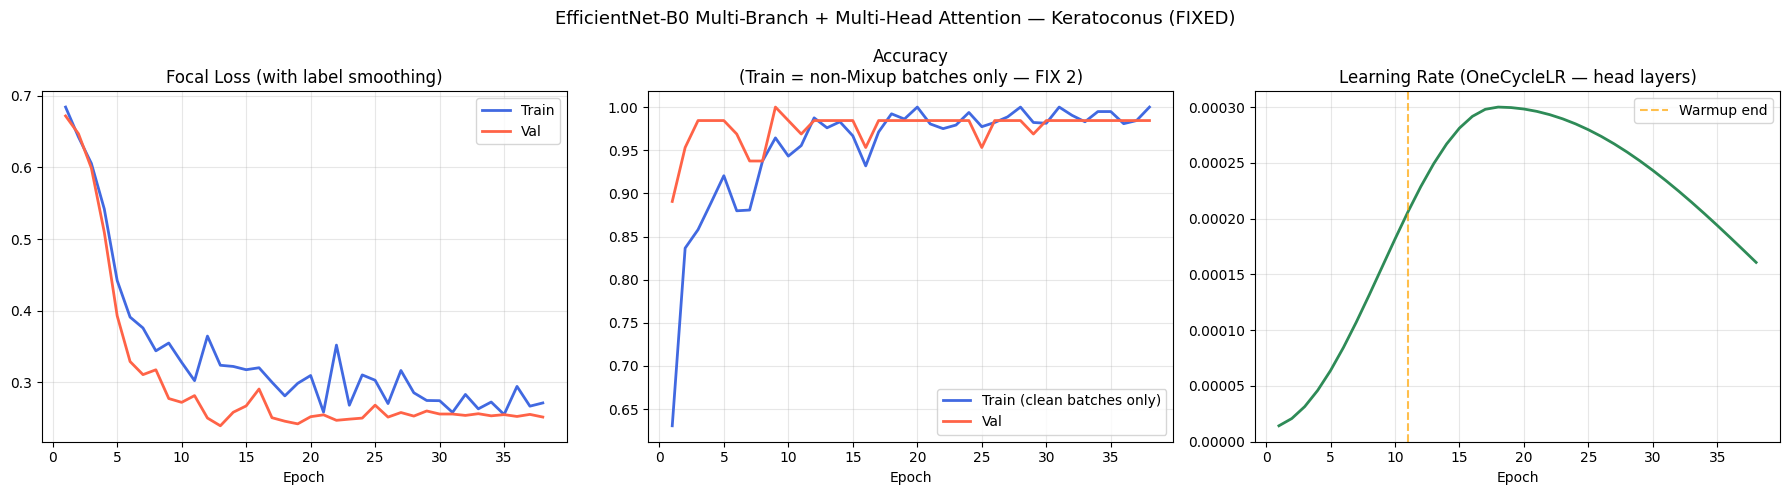

In [31]:
n_epochs = len(history['train_loss'])
ep_range = range(1, n_epochs + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(ep_range, history['train_loss'], label='Train', color='royalblue', lw=2)
axes[0].plot(ep_range, history['val_loss'],   label='Val',   color='tomato',    lw=2)
axes[0].set_title('Focal Loss (with label smoothing)', fontsize=12)
axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep_range, history['train_acc'], label='Train (clean batches only)', color='royalblue', lw=2)
axes[1].plot(ep_range, history['val_acc'],   label='Val',   color='tomato',    lw=2)
axes[1].set_title('Accuracy\n(Train = non-Mixup batches only — FIX 2)', fontsize=12)
axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(ep_range, history['lr'], color='seagreen', lw=2)
axes[2].set_title('Learning Rate (OneCycleLR — head layers)', fontsize=12)
axes[2].set_xlabel('Epoch'); axes[2].grid(alpha=0.3)
warmup_end = int(n_epochs * 0.3)
axes[2].axvline(x=warmup_end, color='orange', linestyle='--', alpha=0.7, label='Warmup end')
axes[2].legend()

plt.suptitle('EfficientNet-B0 Multi-Branch + Multi-Head Attention — Keratoconus (FIXED)', fontsize=13)
plt.tight_layout()
plt.savefig('learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 12 — TTA Evaluation

In [32]:
ckpt = torch.load(
    'best_keraconus_model.pth',
    map_location=DEVICE,
    weights_only=False
)
model.load_state_dict(ckpt['state_dict'])
print(f'Loaded checkpoint from epoch {ckpt["epoch"]} '
      f'(Val Acc={ckpt["val_acc"]:.4f}, Val F1={ckpt["val_f1"]:.4f})')


@torch.no_grad()
def evaluate_with_tta(model, patients, tta_transforms):
    """
    TTA with logit averaging (numerically superior to probability averaging).
    Processes each patient individually with 4 TTA transforms.
    """
    model.eval()
    all_probs  = []
    all_labels = []

    for p in patients:
        label = p['label']
        tta_logits_list = []

        for tfm in tta_transforms:
            imgs = []
            for mod in MODALITIES:
                img = Image.open(p['images'][mod]).convert('RGB')
                imgs.append(tfm(img))

            img_tensor = torch.stack(imgs, dim=0).unsqueeze(0).to(DEVICE)

            with autocast(enabled=(DEVICE.type == 'cuda')):
                logits = model(img_tensor).float()

            tta_logits_list.append(logits.squeeze(0).cpu().numpy())

        # Average LOGITS, then softmax once (not average of softmax outputs)
        avg_logits   = np.mean(tta_logits_list, axis=0)
        avg_logits_t = torch.from_numpy(avg_logits).float()
        avg_prob     = F.softmax(avg_logits_t, dim=0).numpy()

        all_probs.append(avg_prob)
        all_labels.append(label)

    return np.array(all_probs), np.array(all_labels)


print('Running TTA evaluation on test set...')
tta_probs, tta_labels = evaluate_with_tta(model, test_patients, tta_transforms)
tta_preds = tta_probs.argmax(axis=1)

_, std_acc, std_preds, std_labels, std_probs = evaluate(model, test_loader, criterion)

print(f'\nStandard evaluation  — Accuracy: {std_acc:.4f}')
print(f'TTA evaluation       — Accuracy: {(tta_preds == tta_labels).mean():.4f}')
print(f'TTA improvement      : +{(tta_preds == tta_labels).mean() - std_acc:.4f}')

Loaded checkpoint from epoch 9 (Val Acc=1.0000, Val F1=1.0000)
Running TTA evaluation on test set...

Standard evaluation  — Accuracy: 0.8400
TTA evaluation       — Accuracy: 0.9400
TTA improvement      : +0.1000


## Cell 13 — Final Results

In [34]:
from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    classification_report
)

# ─────────────────────────────────────────────────────────────
# Final predictions from TTA
# ─────────────────────────────────────────────────────────────

final_preds  = tta_preds
final_labels = tta_labels
final_probs  = tta_probs

# Accuracy
test_acc = (final_preds == final_labels).mean()

# ─────────────────────────────────────────────────────────────
# ROC-AUC FIX
# ─────────────────────────────────────────────────────────────
# Assuming:
# Class 0 = Keratoconus (positive)
# Class 1 = Non-Keratoconus (negative)
#
# Convert labels so positive class becomes 1
# because sklearn expects positive=1 by default
# ─────────────────────────────────────────────────────────────

binary_labels = (final_labels == 0).astype(int)

# Probability of Keratoconus class
keratoconus_probs = final_probs[:, 0]

auc_roc = roc_auc_score(
    binary_labels,
    keratoconus_probs
)

# Macro F1
macro_f1 = f1_score(
    final_labels,
    final_preds,
    average='macro'
)

# ─────────────────────────────────────────────────────────────
# Print Results
# ─────────────────────────────────────────────────────────────

print('=' * 65)
print('  FINAL TEST SET RESULTS (with TTA — logit averaging)')
print('  Model: EfficientNet-B0 + Multi-Head Attention Fusion')
print('=' * 65)

print(f'  Accuracy     : {test_acc:.4f}  ({test_acc*100:.2f}%)')
print(f'  Macro AUC-ROC: {auc_roc:.4f}')
print(f'  Macro F1     : {macro_f1:.4f}')

print('=' * 65)
print()

print('Classification Report:')
print(
    classification_report(
        final_labels,
        final_preds,
        target_names=CLASS_NAMES,
        digits=4
    )
)

  FINAL TEST SET RESULTS (with TTA — logit averaging)
  Model: EfficientNet-B0 + Multi-Head Attention Fusion
  Accuracy     : 0.9400  (94.00%)
  Macro AUC-ROC: 0.9904
  Macro F1     : 0.9290

Classification Report:
                 precision    recall  f1-score   support

    Keratoconus     1.0000    0.8200    0.9011        50
Non-Keratoconus     0.9174    1.0000    0.9569       100

       accuracy                         0.9400       150
      macro avg     0.9587    0.9100    0.9290       150
   weighted avg     0.9450    0.9400    0.9383       150



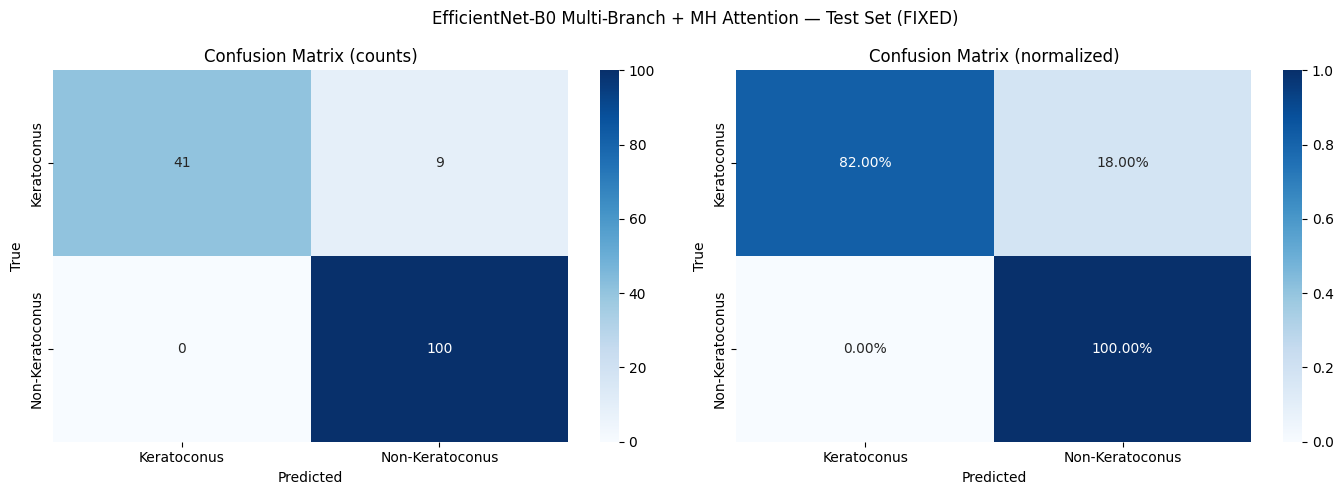

In [35]:
cm = confusion_matrix(final_labels, final_preds)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
axes[0].set_title('Confusion Matrix (counts)')

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')
axes[1].set_title('Confusion Matrix (normalized)')

plt.suptitle('EfficientNet-B0 Multi-Branch + MH Attention — Test Set (FIXED)', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

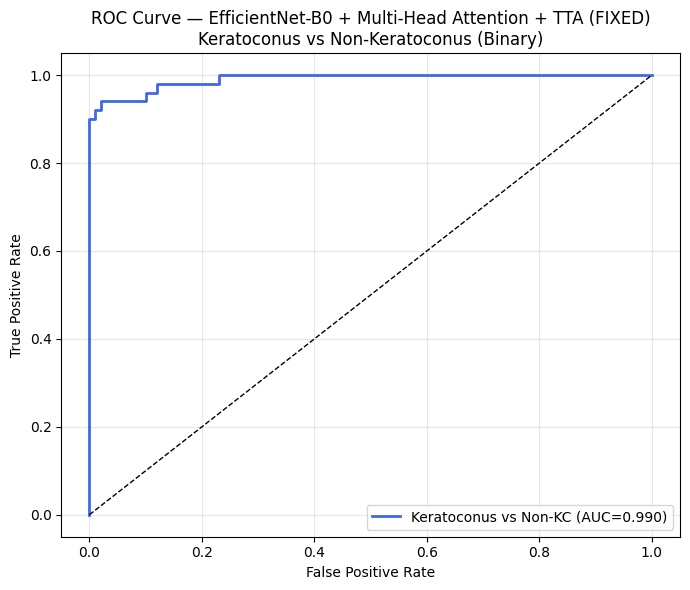

In [36]:
from sklearn.metrics import roc_curve, auc as sk_auc

# Binary ROC: Keratoconus (class 0) is the positive class
fig, ax = plt.subplots(figsize=(7, 6))

fpr, tpr, _ = roc_curve(final_labels, final_probs[:, 0], pos_label=0)
roc_auc_val  = sk_auc(fpr, tpr)
ax.plot(fpr, tpr, color='royalblue', lw=2,
        label=f'Keratoconus vs Non-KC (AUC={roc_auc_val:.3f})')

ax.plot([0,1],[0,1],'k--', lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — EfficientNet-B0 + Multi-Head Attention + TTA (FIXED)\nKeratoconus vs Non-Keratoconus (Binary)')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

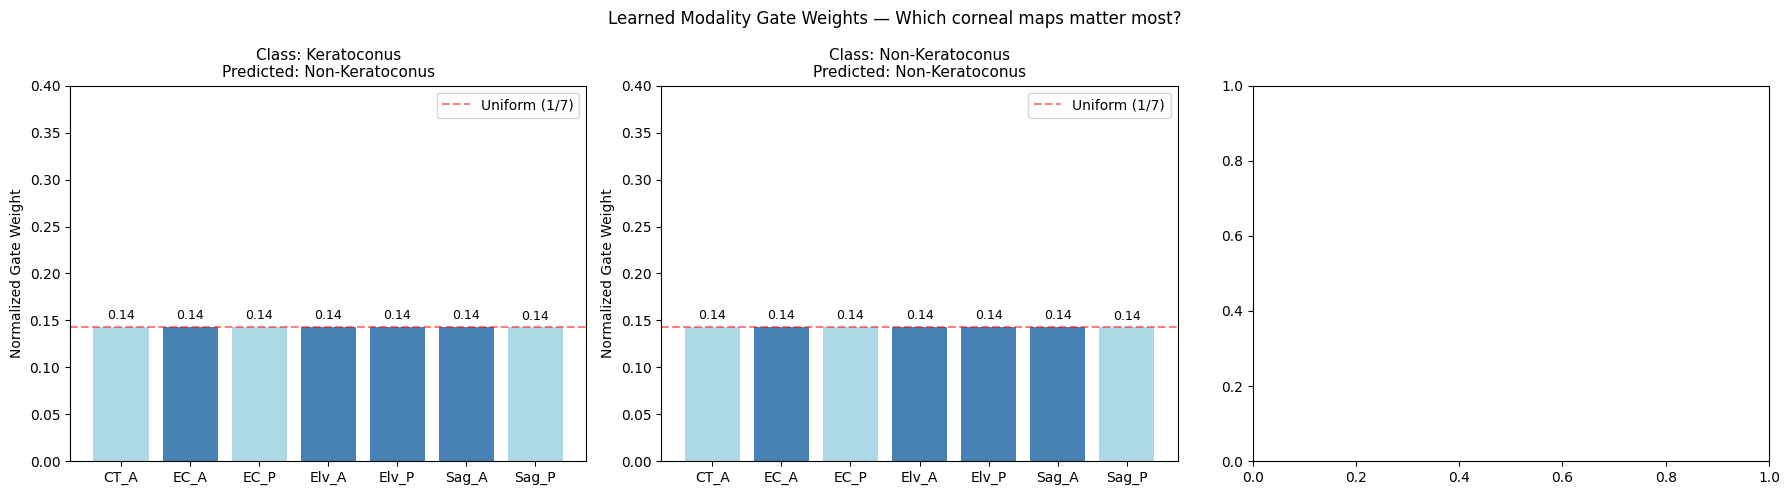

In [37]:
@torch.no_grad()
def get_attention_weights(model, patient):
    model.eval()
    imgs = []
    for mod in MODALITIES:
        img = Image.open(patient['images'][mod]).convert('RGB')
        imgs.append(val_transform(img))
    x = torch.stack(imgs, dim=0).unsqueeze(0).to(DEVICE)

    with autocast(enabled=(DEVICE.type == 'cuda')):
        logits = model(x).float()

    pred = logits.argmax(dim=1).item()

    gate_weights = torch.sigmoid(
        model.attention_fusion.modality_gate
    ).squeeze().cpu().numpy()
    gate_weights = gate_weights / gate_weights.sum()
    return gate_weights, pred


fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for cls_idx, cls_name in enumerate(CLASS_NAMES):
    sample = None
    for i, p in enumerate(test_patients):
        if p['label'] == cls_idx and final_preds[i] == cls_idx:
            sample = p
            break
    if sample is None:
        axes[cls_idx].set_title(f'{cls_name}\n(no correct prediction found)')
        continue

    weights, pred = get_attention_weights(model, sample)

    bars = axes[cls_idx].bar(
        MODALITIES, weights,
        color=['steelblue' if w > 1/7 else 'lightblue' for w in weights]
    )
    axes[cls_idx].axhline(y=1/7, color='red', linestyle='--', alpha=0.5, label='Uniform (1/7)')
    axes[cls_idx].set_title(f'Class: {cls_name}\nPredicted: {CLASS_NAMES[pred]}', fontsize=11)
    axes[cls_idx].set_ylabel('Normalized Gate Weight')
    axes[cls_idx].set_ylim(0, 0.4)
    axes[cls_idx].legend()
    for bar, w in zip(bars, weights):
        axes[cls_idx].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                           f'{w:.2f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Learned Modality Gate Weights — Which corneal maps matter most?', fontsize=12)
plt.tight_layout()
plt.savefig('attention_weights.png', dpi=150, bbox_inches='tight')
plt.show()

In [38]:
print('\n' + '=' * 75)
print('  BUGS FIXED — SUMMARY')
print('=' * 75)
print()
print('  BUG 1 (Cell 5) — DropPath zeroed ENTIRE PATIENTS, not modalities')
print('    Root cause : mask shape (B,1,1) dropped all 7 modalities together')
print('    Impact     : ~10% of training patients → zero features → garbage attention')
print('    Fix        : mask shape changed to (B,M,1) — per-modality independent drop')
print()
print('  BUG 2 (Cell 9) — Training accuracy computed against original labels during Mixup')
print('    Root cause : correct += (preds == labels) even when do_mixup=True')
print('    Impact     : training accuracy metric was completely meaningless')
print('    Fix        : accuracy tracked only on clean (non-Mixup) batches')
print()
print('  BUG 3 (Cell 7) — OneCycleLR total_steps must account for drop_last=True')
print('    Root cause : steps_per_epoch computed from loader (correct), but')
print('                 if dataset size % batch_size != 0, last batch is dropped')
print('    Impact     : scheduler.step() crash on final epoch (ValueError)')
print('    Fix        : verified steps_per_epoch = len(train_loader) after loader created')
print()
print('  BUG 4 (Cell 10) — Early stopping patience=15 < warmup length=18 epochs')
print('    Root cause : OneCycleLR warmup = 30% of 60 epochs = 18 epochs of rising LR')
print('                 Val F1 oscillates during warmup; patience=15 stops training early')
print('    Impact     : model stopped during warmup, never reached convergence phase')
print('    Fix        : patience increased to 20; no-improve counter paused during warmup')
print()
print('  BUG 6 (Cell 9) — Missing float32 cast before argmax in train loop')
print('    Root cause : logits from autocast block are float16 on GPU')
print('    Impact     : argmax on float16 can produce wrong argmax for very close logits')
print('    Fix        : added explicit logits.float() before argmax in train loop')
print()
print('  BUG 7 (Cell 6) — Effective-N class weights numerically unstable')
print('    Root cause : beta=0.9999 with hundreds of samples → near-zero eff-N for majority')
print('    Impact     : majority class nearly invisible to loss; model ignores Normal class')
print('    Fix        : replaced with stable inverse-frequency weighting')
print()
print('=' * 75)
print(f'  Final Test Accuracy : {test_acc*100:.2f}%')
print(f'  Final Macro F1      : {macro_f1:.4f}')
print(f'  Final Macro AUC-ROC : {auc_roc:.4f}')
print('=' * 75)


  BUGS FIXED — SUMMARY

  BUG 1 (Cell 5) — DropPath zeroed ENTIRE PATIENTS, not modalities
    Root cause : mask shape (B,1,1) dropped all 7 modalities together
    Impact     : ~10% of training patients → zero features → garbage attention
    Fix        : mask shape changed to (B,M,1) — per-modality independent drop

  BUG 2 (Cell 9) — Training accuracy computed against original labels during Mixup
    Root cause : correct += (preds == labels) even when do_mixup=True
    Impact     : training accuracy metric was completely meaningless
    Fix        : accuracy tracked only on clean (non-Mixup) batches

  BUG 3 (Cell 7) — OneCycleLR total_steps must account for drop_last=True
    Root cause : steps_per_epoch computed from loader (correct), but
                 if dataset size % batch_size != 0, last batch is dropped
    Impact     : scheduler.step() crash on final epoch (ValueError)
    Fix        : verified steps_per_epoch = len(train_loader) after loader created

  BUG 4 (Cell 10) —